# Predict Accessibility for EFS.fa

This notebook loads the sequences in `EFS.fa`, pads each sequence to a supported AlphaGenome input length, predicts DNase accessibility across all available Homo sapiens tracks, summarizes the strongest accessibility signals, and visualizes a sampled subset of tracks.

In [1]:
from pathlib import Path
import os
import subprocess

from alphagenome import colab_utils
from alphagenome.models import dna_client
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 120

/opt/anaconda3/envs/alphagenome-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set the AlphaGenome API key from 1Password if it's not already set in the environment.
if 'ALPHA_GENOME_API_KEY' not in os.environ:
    os.environ['ALPHA_GENOME_API_KEY'] = subprocess.check_output(
        ['op', 'read', 'op://Private/AlphaGenome API Credential/credential'],
        text=True,
    ).strip()

dna_model = dna_client.create(colab_utils.get_api_key())

In [3]:
efs_path = Path('./EFS.fa')
supported_lengths = sorted(dna_client.SUPPORTED_SEQUENCE_LENGTHS.values())


def read_fasta(path: Path) -> list[tuple[str, str]]:
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if header is not None:
                    records.append((header, ''.join(chunks).upper()))
                header = line[1:]
                chunks = []
            else:
                chunks.append(line)

    if header is not None:
        records.append((header, ''.join(chunks).upper()))

    if not records:
        raise ValueError(f'No FASTA records found in {path}.')

    return records


def choose_supported_length(length: int) -> int:
    for supported_length in supported_lengths:
        if length <= supported_length:
            return supported_length
    raise ValueError(
        'Sequence is longer than the largest AlphaGenome-supported length: '
        f'{length} > {supported_lengths[-1]}'
    )


def normalize_sequence(sequence: str) -> tuple[str, int, int, int]:
    invalid_bases = sorted(set(sequence) - set('ACGTN'))
    if invalid_bases:
        raise ValueError(
            'Sequences must contain only A, C, G, T, or N. '
            f'Found invalid bases: {invalid_bases}'
        )

    target_length = choose_supported_length(len(sequence))
    left_padding = (target_length - len(sequence)) // 2
    right_padding = target_length - len(sequence) - left_padding
    normalized = 'N' * left_padding + sequence + 'N' * right_padding
    return normalized, target_length, left_padding, left_padding + len(sequence)


def make_track_label(row: pd.Series) -> str:
    label_parts = [f"track {row['track_index']}"]
    for column in ['cell_type', 'name', 'ontology_curie', 'biosample_name']:
        value = row.get(column)
        if pd.notna(value) and value not in label_parts:
            label_parts.append(str(value))
    return ' | '.join(label_parts)

In [4]:
records = read_fasta(efs_path)

prepared_records = []
for sequence_name, sequence in records:
    normalized_sequence, model_length, insert_start, insert_end = normalize_sequence(sequence)
    prepared_records.append(
        {
            'sequence_name': sequence_name,
            'original_length': len(sequence),
            'model_length': model_length,
            'insert_start': insert_start,
            'insert_end': insert_end,
            'normalized_sequence': normalized_sequence,
        }
    )

sequence_table = pd.DataFrame(prepared_records)
sequence_table[
    ['sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end']
].copy()

,sequence_name,original_length,model_length,insert_start,insert_end
0,MM-EFS-1,4398,16384,5993,10391
1,MM-EFS-2,4398,16384,5993,10391
2,MM-EFS-3,4398,16384,5993,10391
3,MM-EFS-4,4398,16384,5993,10391
4,MM-EFS-5,4398,16384,5993,10391
5,MM-EFS-6,4398,16384,5993,10391
6,MM-EFS-7,4398,16384,5993,10391
7,MM-EFS-8,4398,16384,5993,10391
8,MM-EFS-9,4398,16384,5993,10391
9,MM-EFS-10,4398,16384,5993,10391


# Predict DNase Accessibility

Setting `ontology_terms=None` requests all available Homo sapiens DNase ontologies exposed by AlphaGenome.

In [5]:
outputs = dna_model.predict_sequences(
    sequences=sequence_table['normalized_sequence'].tolist(),
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=None,
    progress_bar=True,
    max_workers=2,
    intervals=None,
)

dnase_outputs = [output.dnase for output in outputs]

{
    'num_sequences': len(dnase_outputs),
    'first_output_shape': dnase_outputs[0].values.shape,
    'first_output_resolution_bp': dnase_outputs[0].resolution,
}

I0406 15:41:23.986886 6829371 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0406 15:41:23.990131 6829830 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(92, generation: 1)
100%|██████████| 10/10 [00:02<00:00,  3.70it/s]


{'num_sequences': 10,
 'first_output_shape': (16384, 305),
 'first_output_resolution_bp': 1}

In [15]:
import anndata as ad

# Build one AnnData object with one observation per sequence-track pair.
# Rows: sequences x tracks. Columns: genomic bins along the shared model input.
resolution_bp = dnase_outputs[0].resolution 
num_bins, num_tracks = dnase_outputs[0].values.shape
num_sequences = len(dnase_outputs)

if any(dnase.values.shape != (num_bins, num_tracks) for dnase in dnase_outputs):
    raise ValueError('All DNase outputs must have the same shape to build a shared-position AnnData matrix.')

track_metadata = dnase_outputs[0].metadata.reset_index(drop=True).copy() # Use the track metadata from the first output as a template for all tracks, since they should be the same across sequences.
track_metadata['track_index'] = track_metadata.index # Add a track index column to the track metadata for later merging with the sequence-level metadata.

X = np.empty((num_sequences * num_tracks, num_bins), dtype=np.float32)
obs_tables = []

for sequence_idx, (sequence_name, dnase) in enumerate(
    zip(sequence_table['sequence_name'], dnase_outputs, strict=True)
):
    row_start = sequence_idx * num_tracks
    row_end = row_start + num_tracks
    X[row_start:row_end, :] = dnase.values.T

    sequence_info = sequence_table.iloc[sequence_idx]
    sequence_obs = track_metadata.copy()
    sequence_obs['sequence_index'] = sequence_idx # Add a sequence index to link back to the sequence-level metadata
    sequence_obs['sequence_name'] = sequence_name # Add the original sequence name as an observation-level annotation
    sequence_obs['original_length'] = int(sequence_info['original_length']) # Original length of the sequence
    sequence_obs['model_length'] = int(sequence_info['model_length']) # Length of the sequence used in the model
    sequence_obs['insert_start'] = int(sequence_info['insert_start']) # Start position of the inserted sequence
    sequence_obs['insert_end'] = int(sequence_info['insert_end']) # End position of the inserted sequence
    sequence_obs['obs_name'] = [
        f"{sequence_name}#track_{track_index}"
        for track_index in sequence_obs['track_index']
    ]
    obs_tables.append(sequence_obs)

obs = pd.concat(obs_tables, ignore_index=True)
obs.index = obs.pop('obs_name')

bin_starts = np.arange(num_bins, dtype=np.int64) * resolution_bp
bin_ends = bin_starts + resolution_bp
reference_sequence = sequence_table.iloc[0]

var = pd.DataFrame({
    'bin_index': np.arange(num_bins, dtype=np.int64),
    'bin_start_bp': bin_starts,
    'bin_end_bp': bin_ends,
    'position_bp': bin_starts,
}) # Create a variable annotation DataFrame with genomic coordinates for each bin. The position_bp is set to the start of the bin for simplicity, but could be set to the center or end if desired.
var.index = [f"bin_{i}" for i in var['bin_index']] # Set the variable index to be the bin names.

# If all sequences have the same insert coordinates, we can add a boolean annotation for whether each bin overlaps with the inserted sequence. This could be useful for downstream analysis to see how the presence of the insert affects DNase accessibility in different tracks.
if sequence_table['insert_start'].eq(reference_sequence['insert_start']).all() and sequence_table['insert_end'].eq(reference_sequence['insert_end']).all():
    # Add a boolean annotation for whether each bin overlaps with the inserted sequence, which should be the same across all sequences since they have the same insert coordinates.
    var['is_insert_bin'] = (
        (bin_starts < int(reference_sequence['insert_end']))
        & (bin_ends > int(reference_sequence['insert_start']))
    )

dnase_adata = ad.AnnData(X=X, obs=obs, var=var)
dnase_adata.uns['output_type'] = 'DNASE'
dnase_adata.uns['organism'] = 'HOMO_SAPIENS'
dnase_adata.uns['num_sequences'] = int(num_sequences)
dnase_adata.uns['num_tracks'] = int(num_tracks)
dnase_adata.uns['track_resolution_bp'] = int(resolution_bp)
dnase_adata.uns['input_sequences'] = sequence_table.normalized_sequence.tolist() # Convert the normalized sequences to a list of strings

dnase_adata

AnnData object with n_obs × n_vars = 3050 × 16384
    obs: 'name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean', 'track_index', 'sequence_index', 'sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end'
    var: 'bin_index', 'bin_start_bp', 'bin_end_bp', 'position_bp', 'is_insert_bin'
    uns: 'output_type', 'organism', 'num_sequences', 'num_tracks', 'track_resolution_bp', 'input_sequences'

In [17]:
dnase_adata.write_h5ad("alphagenome_dnase_prediction_adata.h5ad")

In [6]:
prediction_summary = sequence_table[
    ['sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end']
].copy()
prediction_summary['num_dnase_tracks'] = [dnase.num_tracks for dnase in dnase_outputs]
prediction_summary['num_bins'] = [dnase.values.shape[0] for dnase in dnase_outputs]
prediction_summary['track_resolution_bp'] = [dnase.resolution for dnase in dnase_outputs]

track_metadata = dnase_outputs[0].metadata.reset_index(drop=True).copy()
track_metadata['track_index'] = track_metadata.index

prediction_summary

,sequence_name,original_length,model_length,insert_start,insert_end,num_dnase_tracks,num_bins,track_resolution_bp
0,MM-EFS-1,4398,16384,5993,10391,305,16384,1
1,MM-EFS-2,4398,16384,5993,10391,305,16384,1
2,MM-EFS-3,4398,16384,5993,10391,305,16384,1
3,MM-EFS-4,4398,16384,5993,10391,305,16384,1
4,MM-EFS-5,4398,16384,5993,10391,305,16384,1
5,MM-EFS-6,4398,16384,5993,10391,305,16384,1
6,MM-EFS-7,4398,16384,5993,10391,305,16384,1
7,MM-EFS-8,4398,16384,5993,10391,305,16384,1
8,MM-EFS-9,4398,16384,5993,10391,305,16384,1
9,MM-EFS-10,4398,16384,5993,10391,305,16384,1


In [7]:
per_sequence_track_scores = []
for sequence_name, dnase in zip(sequence_table['sequence_name'], dnase_outputs, strict=True):
    score_table = track_metadata.copy()
    score_table['sequence_name'] = sequence_name
    score_table['mean_accessibility'] = dnase.values.mean(axis=0)
    score_table['max_accessibility'] = dnase.values.max(axis=0)
    per_sequence_track_scores.append(score_table)

track_scores = pd.concat(per_sequence_track_scores, ignore_index=True)
track_scores

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,track_index,sequence_name,mean_accessibility,max_accessibility
0,CL:0000047 DNase-seq,.,DNase-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,encode,single,False,1.554501,0,MM-EFS-1,0.017835,3.890625
1,CL:0000084 DNase-seq,.,DNase-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,0.151404,1,MM-EFS-1,0.048564,21.750000
2,CL:0000115 DNase-seq,.,DNase-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,encode,paired,False,0.513028,2,MM-EFS-1,0.025909,10.500000
3,CL:0000127 DNase-seq,.,DNase-seq,CL:0000127,astrocyte,primary_cell,unknown,encode,single,False,0.845752,3,MM-EFS-1,0.011829,1.453125
4,CL:0000134 DNase-seq,.,DNase-seq,CL:0000134,mesenchymal stem cell,in_vitro_differentiated_cells,embryonic,encode,paired,False,0.540044,4,MM-EFS-1,0.016357,3.687500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3045,UBERON:0036149 DNase-seq,.,DNase-seq,UBERON:0036149,suprapubic skin,tissue,adult,encode,paired,False,0.485925,300,MM-EFS-10,0.032490,3.687500
3046,UBERON:8300001 DNase-seq,.,DNase-seq,UBERON:8300001,right forelimb,tissue,embryonic,encode,paired,False,1.431965,301,MM-EFS-10,0.024285,3.843750
3047,UBERON:8300002 DNase-seq,.,DNase-seq,UBERON:8300002,left forelimb,tissue,embryonic,encode,paired,False,1.206352,302,MM-EFS-10,0.026416,2.015625
3048,UBERON:8300003 DNase-seq,.,DNase-seq,UBERON:8300003,right hindlimb,tissue,embryonic,encode,paired,False,1.254712,303,MM-EFS-10,0.021851,3.953125


In [8]:
track_scores.groupby('track_index', as_index=False).agg(
        mean_accessibility=('mean_accessibility', 'mean'),
        max_accessibility=('max_accessibility', 'max'),
    )

,track_index,mean_accessibility,max_accessibility
0,0,0.013723,4.906250
1,1,0.037600,24.125000
2,2,0.020976,12.187500
3,3,0.008501,1.734375
4,4,0.013499,4.843750
...,...,...,...
300,300,0.030030,4.875000
301,301,0.021779,6.343750
302,302,0.023849,3.109375
303,303,0.018728,7.000000


In [9]:
metadata_columns = [
    column
    for column in [
        'track_index',
        'name',
        'cell_type',
        'ontology_curie',
        'biosample_name',
        'biosample_type',
        'developmental_stage',
        'assay',
    ]
    if column in track_metadata.columns
]

global_track_ranking = (
    track_scores.groupby('track_index', as_index=False)
    .agg(
        mean_accessibility=('mean_accessibility', 'mean'),
        max_accessibility=('max_accessibility', 'max'),
    )
    .merge(track_metadata[metadata_columns], on='track_index', how='left')
    .sort_values(['mean_accessibility', 'max_accessibility'], ascending=False)
    .reset_index(drop=True)
 )
global_track_ranking

,track_index,mean_accessibility,max_accessibility,name,ontology_curie,biosample_name,biosample_type
0,173,0.150158,23.87500,EFO:0005720 DNase-seq,EFO:0005720,SK-MEL-5,cell_line
1,93,0.129360,17.87500,CL:2000045 DNase-seq,CL:2000045,foreskin melanocyte,primary_cell
2,248,0.077486,9.75000,UBERON:0001875 DNase-seq,UBERON:0001875,globus pallidus,tissue
3,225,0.066154,7.00000,UBERON:0000988 DNase-seq,UBERON:0000988,pons,tissue
4,247,0.048530,7.46875,UBERON:0001874 DNase-seq,UBERON:0001874,putamen,tissue
...,...,...,...,...,...,...,...
300,78,0.008388,5.21875,CL:0011021 DNase-seq,CL:0011021,fibroblast of upper back skin,primary_cell
301,193,0.008313,5.59375,EFO:0007748 DNase-seq,EFO:0007748,EH,cell_line
302,211,0.008233,4.34375,NTR:0000525 DNase-seq,NTR:0000525,fibroblast of skin of right biceps,primary_cell
303,62,0.007308,2.25000,CL:0002553 DNase-seq,CL:0002553,fibroblast of lung,primary_cell


In [10]:
sequence_level_top_tracks = (
    track_scores.sort_values(
        ['sequence_name', 'mean_accessibility'],
        ascending=[True, False],
    )
    .groupby('sequence_name')
    .head(10)
    .reset_index(drop=True)
 )

prediction_summary.to_csv('efs_prediction_summary.csv', index=False)
track_scores.to_csv('efs_dnase_track_scores.csv', index=False)
global_track_ranking.to_csv('efs_dnase_global_track_ranking.csv', index=False)
sequence_level_top_tracks.to_csv('efs_dnase_top_tracks_per_sequence.csv', index=False)

global_track_ranking.head(10)

,track_index,mean_accessibility,max_accessibility,name,ontology_curie,biosample_name,biosample_type
0,173,0.150158,23.87500,EFO:0005720 DNase-seq,EFO:0005720,SK-MEL-5,cell_line
1,93,0.129360,17.87500,CL:2000045 DNase-seq,CL:2000045,foreskin melanocyte,primary_cell
2,248,0.077486,9.75000,UBERON:0001875 DNase-seq,UBERON:0001875,globus pallidus,tissue
3,225,0.066154,7.00000,UBERON:0000988 DNase-seq,UBERON:0000988,pons,tissue
4,247,0.048530,7.46875,UBERON:0001874 DNase-seq,UBERON:0001874,putamen,tissue
5,143,0.046475,18.62500,EFO:0002793 DNase-seq,EFO:0002793,HL-60,cell_line
6,275,0.045990,14.62500,UBERON:0002740 DNase-seq,UBERON:0002740,posterior cingulate gyrus,tissue
7,290,0.044799,6.21875,UBERON:0008953 DNase-seq,UBERON:0008953,lower lobe of left lung,tissue
8,274,0.043731,16.12500,UBERON:0002626 DNase-seq,UBERON:0002626,head of caudate nucleus,tissue
9,46,0.043511,34.00000,CL:0002061 DNase-seq,CL:0002061,T-helper 9 cell,primary_cell


# Visualize Sampled Tracks

The full DNase output contains many tracks, so the plot below uses the highest-mean tracks across the EFS sequences and highlights the original insert span within the padded model input.

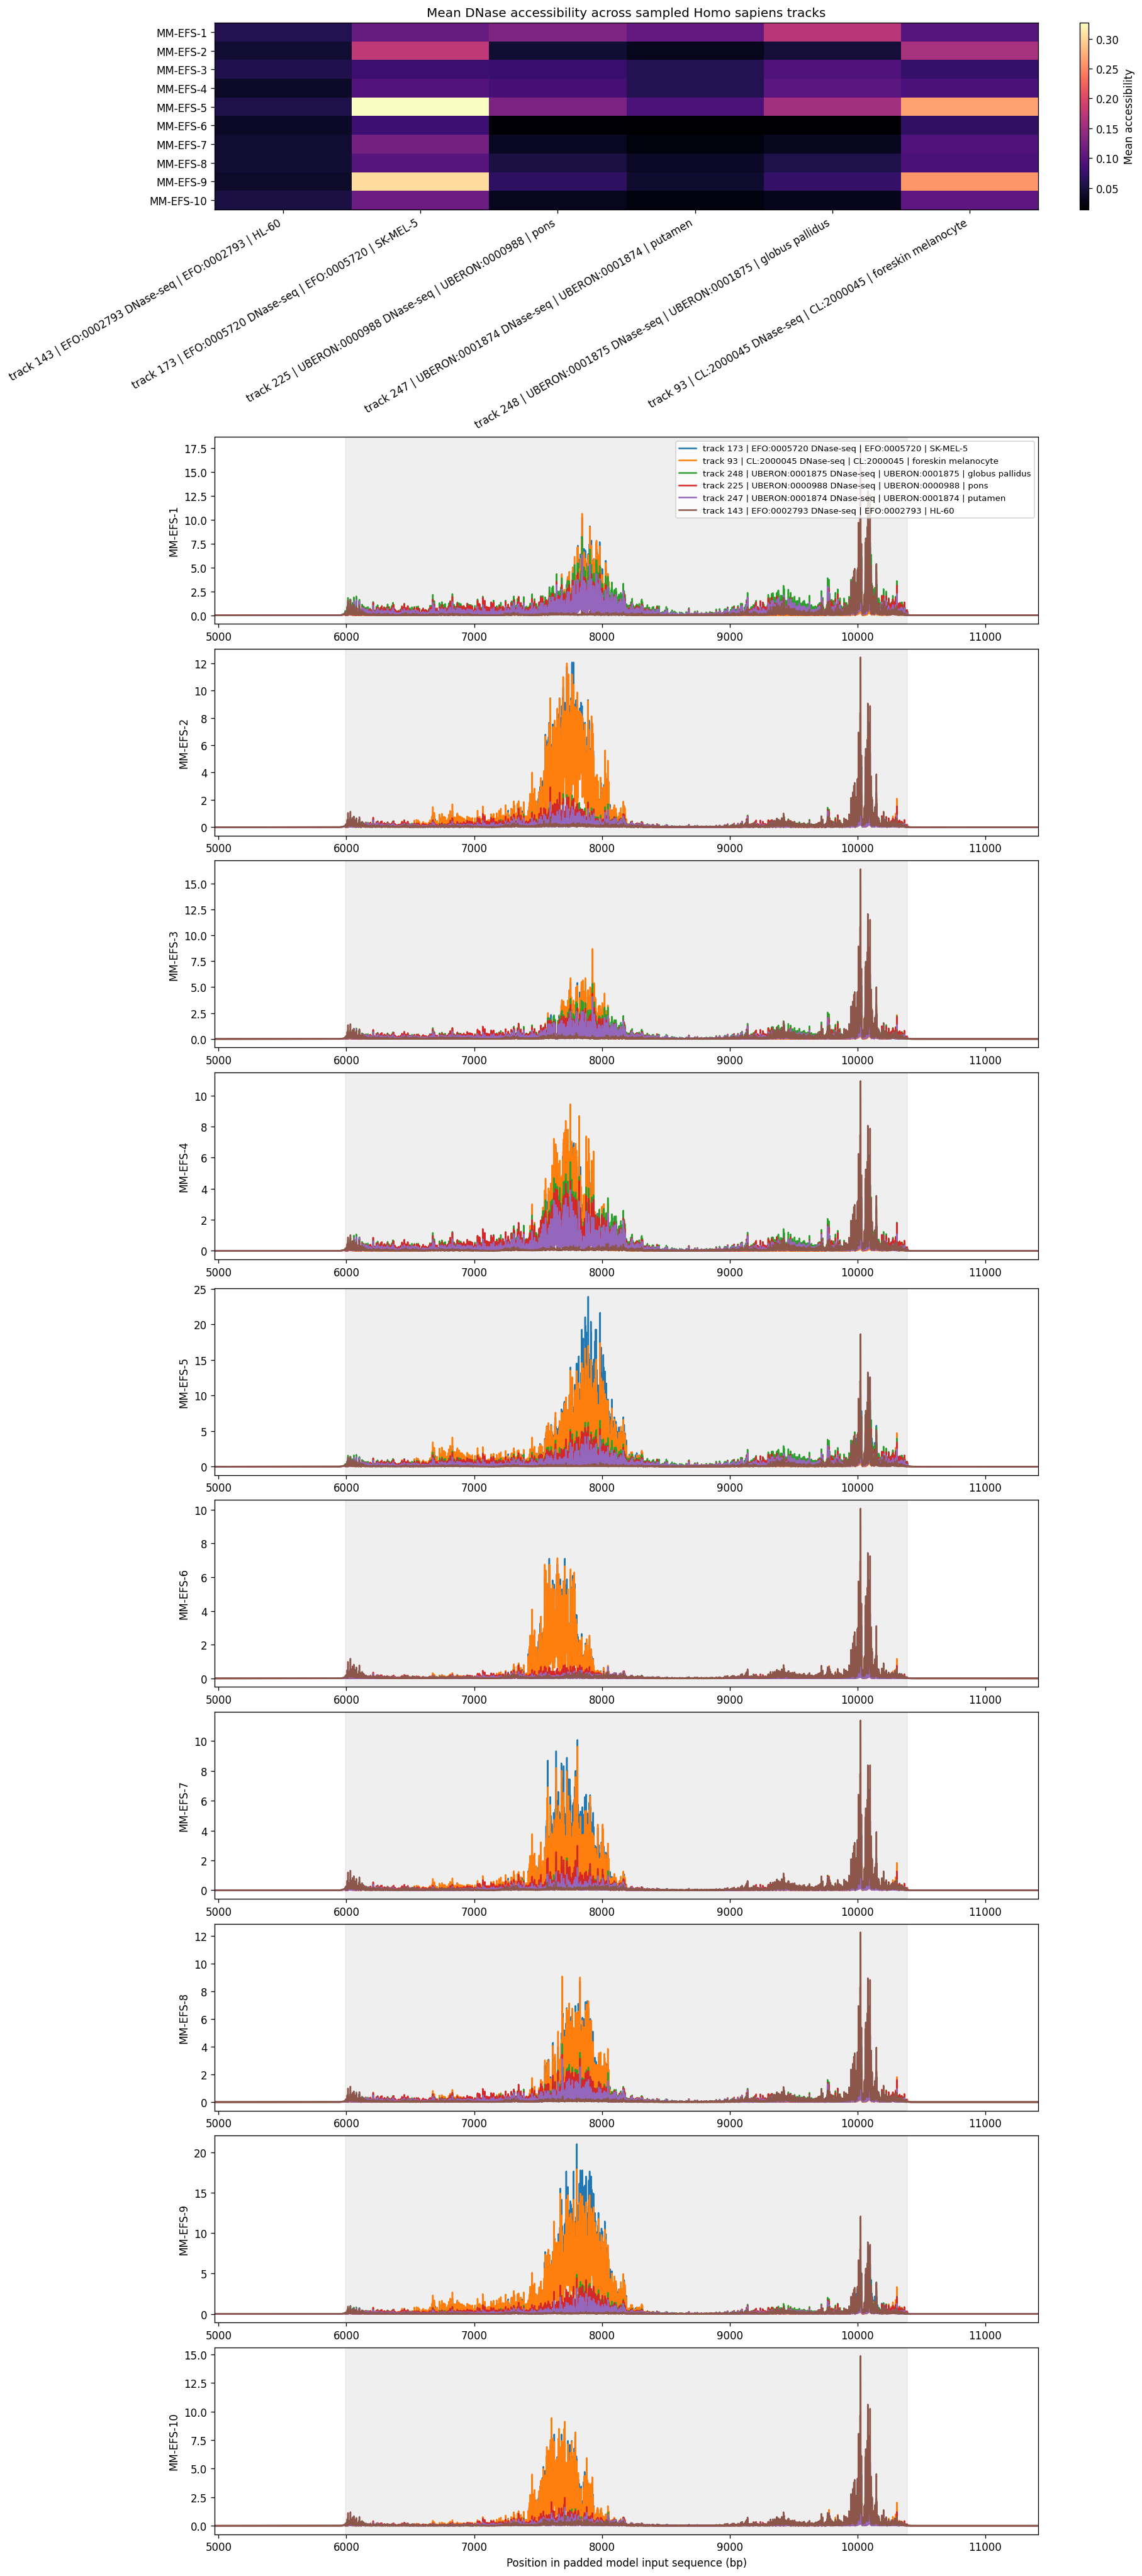

In [11]:
sampled_track_indices = global_track_ranking.head(
    min(6, len(global_track_ranking))
)['track_index'].tolist()

sampled_track_rows = track_metadata.loc[sampled_track_indices].copy()
sampled_track_rows['plot_label'] = sampled_track_rows.apply(make_track_label, axis=1)

mean_heatmap = (
    track_scores[track_scores['track_index'].isin(sampled_track_indices)]
    .merge(
        sampled_track_rows[['track_index', 'plot_label']],
        on='track_index',
        how='left',
    )
    .pivot(index='sequence_name', columns='plot_label', values='mean_accessibility')
    .loc[sequence_table['sequence_name']]
 )

fig, axes = plt.subplots(
    nrows=len(sequence_table) + 1,
    ncols=1,
    figsize=(15, 3 * len(sequence_table) + 4),
    constrained_layout=True,
 )

heatmap_ax = axes[0]
heatmap = mean_heatmap.to_numpy(dtype=float)
image = heatmap_ax.imshow(heatmap, aspect='auto', cmap='magma')
heatmap_ax.set_xticks(np.arange(mean_heatmap.shape[1]))
heatmap_ax.set_xticklabels(mean_heatmap.columns, rotation=30, ha='right')
heatmap_ax.set_yticks(np.arange(mean_heatmap.shape[0]))
heatmap_ax.set_yticklabels(mean_heatmap.index)
heatmap_ax.set_title('Mean DNase accessibility across sampled Homo sapiens tracks')
fig.colorbar(image, ax=heatmap_ax, label='Mean accessibility')

for axis_offset, (_, row) in enumerate(sequence_table.iterrows(), start=1):
    dnase = dnase_outputs[axis_offset - 1]
    ax = axes[axis_offset]
    x_positions = np.arange(dnase.values.shape[0]) * dnase.resolution

    for track_index, plot_label in zip(
        sampled_track_indices,
        sampled_track_rows['plot_label'],
        strict=True,
    ):
        ax.plot(x_positions, dnase.values[:, track_index], linewidth=1.5, label=plot_label)

    ax.axvspan(row['insert_start'], row['insert_end'], color='lightgrey', alpha=0.35)
    window_start = max(0, row['insert_start'] - 1024)
    window_end = min(row['model_length'], row['insert_end'] + 1024)
    ax.set_xlim(window_start, window_end)
    ax.set_ylabel(row['sequence_name'])
    if axis_offset == 1:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position in padded model input sequence (bp)')
plt.show()

# Peak Calling